## Imports

In [26]:
import os 
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve

## Exploring the folder structure
We check that our data folders are visible from the notebook.

In [27]:
print(os.listdir(".")) 

['.DS_Store', '.gitignore', 'best_svm.pkl', 'lr.pkl', 'pca.pkl', 'r.pkl', 'test', 'train', 'val', 'zoidberg.ipynb']


## Exploring the Data
We count how many images are in each folder to understand our dataset.

In [28]:
print(len(os.listdir("test/NORMAL")))
print(len(os.listdir("test/PNEUMONIA")))
print(len(os.listdir("train/NORMAL")))
print(len(os.listdir("train/PNEUMONIA")))
print(len(os.listdir("val/NORMAL")))
print(len(os.listdir("val/PNEUMONIA")))


234
390
1342
3876
9
9


We notice a class imbalance in the training set: 1342 NORMAL vs 3876 PNEUMONIA. 
This could bias our model toward predicting pneumonia.

## Visualizing the Data
We display some sample images to understand what we're working with.

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

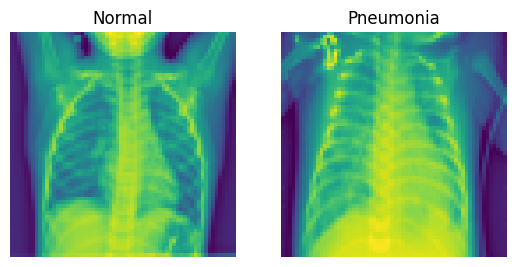

In [29]:
photos = os.listdir("train/NORMAL")
photos2 = os.listdir("train/PNEUMONIA")
first = os.path.join("train/NORMAL",photos[1])
second = os.path.join("train/PNEUMONIA",photos2[1])
imgsize = (64 , 64)
plt.subplot(1,2,1)
plt.imshow(Image.open(first).resize(imgsize))
plt.title("Normal")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(Image.open(second).resize(imgsize))
plt.title("Pneumonia")
plt.axis("off")




## Loading and Preprocessing Images
We load all images, convert them to grayscale, resize them to 64x64, 
and store them as numpy arrays for machine learning.

In [30]:

def loadimages(folder, label):
    X = []
    Y = []
    imgresize = (64,64)
    photos = os.listdir(folder)
    for x in photos:
        if x.endswith(".jpeg"):
          photo = os.path.join(folder,x)
          img = Image.open(photo).convert("L").resize(imgresize)
          X.append(np.array(img)/255)
          Y.append(label)
    return X,Y
  


## Loading All Images
We load all images from train, combine normal and pneumonia into one dataset.

In [31]:

X_normal, Y_normal = loadimages("train/NORMAL", 0)
X_pneumonia, Y_pneumonia = loadimages("train/PNEUMONIA", 1)
X = X_normal + X_pneumonia
Y = Y_normal + Y_pneumonia
print(len(X))
print(len(Y))


5216
5216


## Flattening Images
We convert images from 2D arrays (64x64) to 1D arrays (4096) so ML models can process them.

In [32]:
X = np.array(X)
Y = np.array(Y)
print(X.shape)
X = X.reshape(len(X), -1)
print(X.shape)


(5216, 64, 64)
(5216, 4096)


## Train/Test Split
We split the training data 80/20. 80% for training, 20% for testing.
The test folder is kept for final evaluation only.

In [33]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_val.shape)
print(len(X_train)/len(X)*100)
print(len(X_val)/len(X)*100)

(4172, 4096)
(1044, 4096)
79.98466257668711
20.015337423312886


## Loading Test Data
We load the test folder images for final evaluation.

In [34]:
X_test_normal, Y_test_normal = loadimages("test/NORMAL", 0)
X_test_pneumonia, Y_test_pneumonia = loadimages("test/PNEUMONIA", 1)
X_test = X_test_normal + X_test_pneumonia
Y_test = Y_test_normal + Y_test_pneumonia
print(len(X_test))

624


## Flattening Test Data
We convert test images to numpy arrays and flatten them to 1D.

In [35]:
X_test = np.array(X_test)
Y_test = np.array(Y_test)
X_test = X_test.reshape(len(X_test), -1)
print(X_test.shape)

(624, 4096)


## PCA - Principal Component Analysis
We reduce features from 4096 to 100. PCA is fitted on training data only.
Then applied to validation and test sets.

In [ ]:
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)
print(X_train_pca.shape)
print(X_val_pca.shape)
print(X_test_pca.shape)

(4172, 70)
(1044, 70)
(624, 70)


## Logistic Regression Classifier
We train a Logistic Regression as our baseline classifier.

In [37]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_pca, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

## Evaluating Logistic Regression
We evaluate the model on the validation set using classification report.

In [38]:
Y_pred = lr.predict(X_val_pca)
print(classification_report(Y_val, Y_pred))

              precision    recall  f1-score   support

           0       0.86      0.93      0.89       287
           1       0.97      0.94      0.96       757

    accuracy                           0.94      1044
   macro avg       0.92      0.94      0.93      1044
weighted avg       0.94      0.94      0.94      1044



## Random Forest Classifier
We train a Random Forest and compare results with Logistic Regression.

In [39]:
r = RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=20, random_state=42)
r.fit(X_train_pca,Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## Evaluating Random Forest
We evaluate the Random Forest on the validation set and compare with Logistic Regression.

In [40]:
Y_pred_r = r.predict(X_val_pca)
print(classification_report(Y_val, Y_pred_r))

              precision    recall  f1-score   support

           0       0.99      0.74      0.84       287
           1       0.91      1.00      0.95       757

    accuracy                           0.92      1044
   macro avg       0.95      0.87      0.90      1044
weighted avg       0.93      0.92      0.92      1044



## Support Vector Machine (SVM)
We train a third classifier and compare with Logistic Regression and Random Forest.

In [41]:
svm = SVC(class_weight='balanced', random_state=42)
svm.fit(X_train_pca, Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Evaluating SVM
We evaluate SVM on the validation set and compare with Logistic Regression and Random Forest.

In [42]:
Y_pred_svm = svm.predict(X_val_pca)
print(classification_report(Y_val, Y_pred_svm))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95       287
           1       0.99      0.97      0.98       757

    accuracy                           0.97      1044
   macro avg       0.96      0.97      0.96      1044
weighted avg       0.97      0.97      0.97      1044



## Cross Validation
We use 5-fold cross validation on the training data to get a more reliable performance estimate.

In [43]:
from sklearn.model_selection import cross_val_score

cv_lr = cross_val_score(lr, X_train_pca, Y_train, cv=5, scoring='recall')
cv_r = cross_val_score(r,  X_train_pca, Y_train, cv=5, scoring='recall')
cv_svm = cross_val_score(svm, X_train_pca, Y_train, cv=5, scoring='recall')

print(f"LR mean recall: {cv_lr.mean():.2f}")
print(f"RF mean recall: {cv_r.mean():.2f}")
print(f"SVM mean recall: {cv_svm.mean():.2f}")

LR mean recall: 0.95
RF mean recall: 0.99
SVM mean recall: 0.97


## Hyperparameter Tuning with GridSearchCV
We use GridSearchCV to find the best parameters for our classifiers.

In [44]:
param_grid = {
    'C': [1, 10],
    'kernel': ['rbf']
}
grid_svm = GridSearchCV(SVC(class_weight='balanced'), param_grid, cv=3, scoring='recall', n_jobs=-1)
grid_svm.fit(X_train_pca, Y_train)
print(grid_svm.best_params_)
best_svm = SVC(C=10, kernel='rbf', class_weight='balanced', random_state=42, probability=True)
best_svm.fit(X_train_pca, Y_train)
Y_pred_best_svm = best_svm.predict(X_val_pca)
print(classification_report(Y_val, Y_pred_best_svm))

{'C': 10, 'kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.96      0.93      0.95       287
           1       0.97      0.99      0.98       757

    accuracy                           0.97      1044
   macro avg       0.97      0.96      0.96      1044
weighted avg       0.97      0.97      0.97      1044



In [45]:
param_grid_lr = {
    'C': [0.1, 1, 10],
    'max_iter': [1000, 2000]
}

grid_lr = GridSearchCV(LogisticRegression(class_weight='balanced'), param_grid_lr, cv=3, scoring='recall', n_jobs=-1)
grid_lr.fit(X_train_pca, Y_train)
print(grid_lr.best_params_)
best_lr = LogisticRegression(C=0.1, max_iter=1000, class_weight='balanced')
best_lr.fit(X_train_pca, Y_train)
Y_pred_best_lr = best_lr.predict(X_val_pca)
print(classification_report(Y_val, Y_pred_best_lr))

{'C': 0.1, 'max_iter': 1000}
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       287
           1       0.97      0.94      0.96       757

    accuracy                           0.94      1044
   macro avg       0.91      0.94      0.92      1044
weighted avg       0.94      0.94      0.94      1044



In [46]:
param_grid_r = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20]
}

grid_r = GridSearchCV(RandomForestClassifier(class_weight='balanced'), param_grid_r, cv=3, scoring='recall', n_jobs=-1)
grid_r.fit(X_train_pca, Y_train)
print(grid_r.best_params_)
best_r = RandomForestClassifier(n_estimators=200, max_depth=20, class_weight='balanced', random_state=42)
best_r.fit(X_train_pca, Y_train)
Y_pred_best_r = best_r.predict(X_val_pca)
print(classification_report(Y_val, Y_pred_best_r))

{'max_depth': 20, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.99      0.74      0.84       287
           1       0.91      1.00      0.95       757

    accuracy                           0.92      1044
   macro avg       0.95      0.87      0.90      1044
weighted avg       0.93      0.92      0.92      1044



## Confusion Matrix
We visualize the predictions of our best model (SVM) to understand errors.

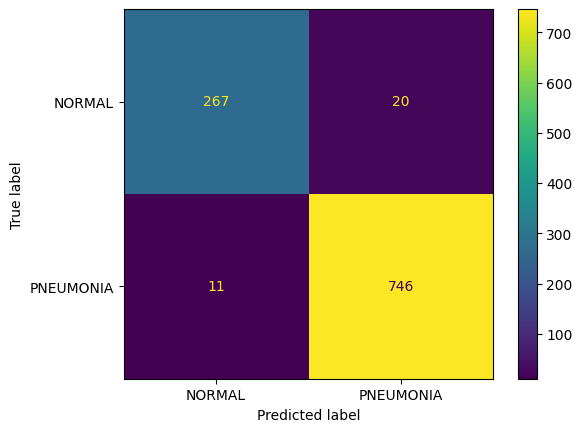

In [47]:
cm = confusion_matrix(Y_val, Y_pred_best_svm)
disp = ConfusionMatrixDisplay(cm, display_labels=['NORMAL', 'PNEUMONIA'])
disp.plot()
plt.show()

## ROC-AUC Score
We evaluate our best model using the ROC-AUC metric.

AUC Score: 1.00


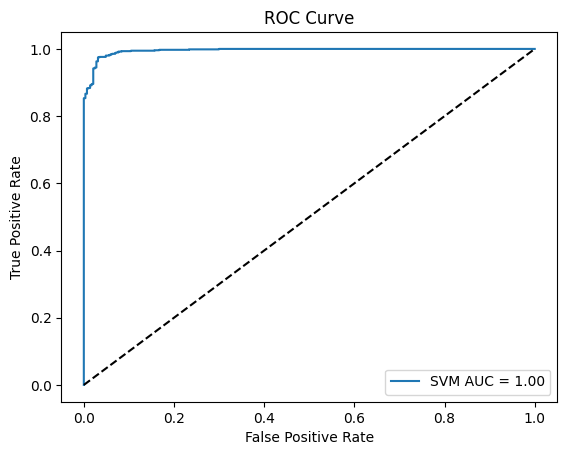

In [48]:
Y_prob = best_svm.predict_proba(X_val_pca)[:, 1]
auc = roc_auc_score(Y_val, Y_prob)
print(f"AUC Score: {auc:.2f}")

fpr, tpr, _ = roc_curve(Y_val, Y_prob)
plt.plot(fpr, tpr, label=f'SVM AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Saving Models
We save our trained models so we can load them later without retraining.

In [49]:
import joblib

joblib.dump(best_svm, 'best_svm.pkl')
joblib.dump(lr, 'lr.pkl')
joblib.dump(r, 'r.pkl')
joblib.dump(pca, 'pca.pkl')

['pca.pkl']

## Final Evaluation on Test Set
We evaluate our best model (SVM) on the unseen test data for the final performance report.

In [50]:
Y_pred_test = best_svm.predict(X_test_pca)
print(classification_report(Y_test, Y_pred_test))



              precision    recall  f1-score   support

           0       0.97      0.38      0.55       234
           1       0.73      0.99      0.84       390

    accuracy                           0.76       624
   macro avg       0.85      0.69      0.70       624
weighted avg       0.82      0.76      0.73       624

